# Sentiment Analysis on Movie Reviews
## RNN-based approach using PyTorch

## 1. Setup & Data Download

In [14]:
from google.colab import files
print("Upload sentiment-analysis-on-movie-reviews.zip:")
uploaded = files.upload()

Upload sentiment-analysis-on-movie-reviews.zip:


Saving sentiment-analysis-on-movie-reviews.zip to sentiment-analysis-on-movie-reviews (4).zip


In [15]:
!unzip -o sentiment-analysis-on-movie-reviews.zip -d data/
!unzip -o data/train.tsv.zip -d data/
!unzip -o data/test.tsv.zip  -d data/
!ls data/

Archive:  sentiment-analysis-on-movie-reviews.zip
  inflating: data/sampleSubmission.csv  
  inflating: data/test.tsv.zip       
  inflating: data/train.tsv.zip      
Archive:  data/train.tsv.zip
  inflating: data/train.tsv          
Archive:  data/test.tsv.zip
  inflating: data/test.tsv           
sampleSubmission.csv  test.tsv	test.tsv.zip  train.tsv  train.tsv.zip


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Analysis & Visualization

In [17]:
train_df = pd.read_csv('data/train.tsv', sep='\t')
test_df  = pd.read_csv('data/test.tsv',  sep='\t')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (156060, 4)
Test shape:  (66292, 3)


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [18]:
print(train_df.info())
print('\nMissing values:\n', train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   PhraseId    156060 non-null  int64 
 1   SentenceId  156060 non-null  int64 
 2   Phrase      156060 non-null  object
 3   Sentiment   156060 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.8+ MB
None

Missing values:
 PhraseId      0
SentenceId    0
Phrase        0
Sentiment     0
dtype: int64


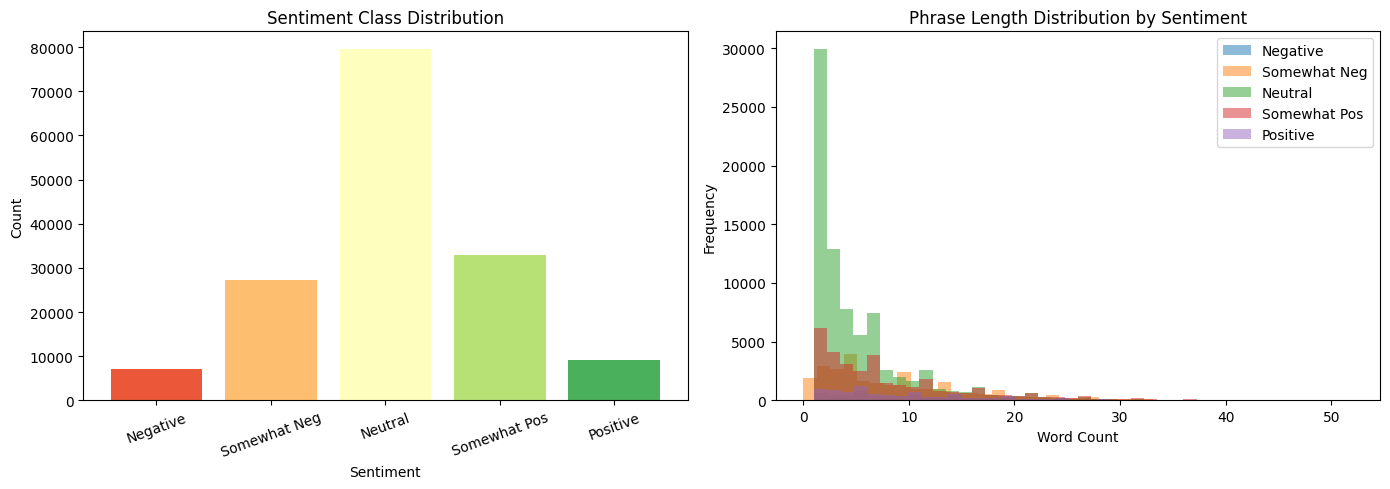

In [19]:
label_names = {0: 'Negative', 1: 'Somewhat Neg', 2: 'Neutral', 3: 'Somewhat Pos', 4: 'Positive'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = train_df['Sentiment'].value_counts().sort_index()
axes[0].bar([label_names[i] for i in counts.index], counts.values, color=sns.color_palette('RdYlGn', 5))
axes[0].set_title('Sentiment Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

train_df['phrase_len'] = train_df['Phrase'].str.split().str.len()
for s in range(5):
    axes[1].hist(train_df[train_df['Sentiment'] == s]['phrase_len'], bins=40, alpha=0.5, label=label_names[s])
axes[1].set_title('Phrase Length Distribution by Sentiment')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
print('Phrase length stats:')
print(train_df['phrase_len'].describe())
print(f'\n95th percentile length: {np.percentile(train_df["phrase_len"], 95):.0f} words')

Phrase length stats:
count    156060.000000
mean          7.203364
std           7.024604
min           0.000000
25%           2.000000
50%           5.000000
75%          10.000000
max          52.000000
Name: phrase_len, dtype: float64

95th percentile length: 22 words


/tmp/ipykernel_2473/2682345325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words, x='word', y='count', palette='Blues_d')


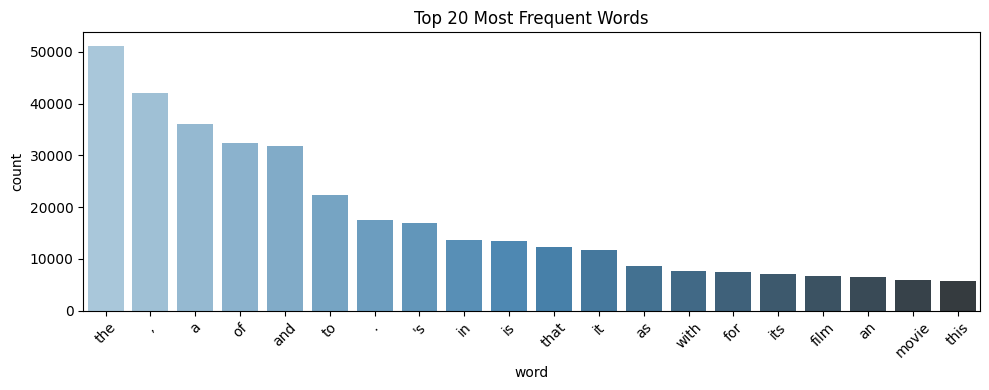

Total unique words: 16531


In [21]:
all_words = ' '.join(train_df['Phrase']).lower().split()
word_freq = Counter(all_words)

top_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])
plt.figure(figsize=(10, 4))
sns.barplot(data=top_words, x='word', y='count', palette='Blues_d')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Total unique words: {len(word_freq)}')

## 3. Preprocessing

In [23]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r"[^a-z\s']", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean'] = train_df['Phrase'].apply(clean_text)
test_df['clean']  = test_df['Phrase'].apply(clean_text)

In [24]:
MIN_FREQ  = 2
MAX_LEN   = 50
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

all_tokens = ' '.join(train_df['clean']).split()
freq = Counter(all_tokens)
vocab = [PAD_TOKEN, UNK_TOKEN] + [w for w, c in freq.items() if c >= MIN_FREQ]

word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocabulary size: {len(vocab)}')

def encode(text, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]
    ids   += [0] * (max_len - len(ids))
    return ids

Vocabulary size: 16198


In [25]:
train_df['encoded'] = train_df['clean'].apply(encode)
test_df['encoded']  = test_df['clean'].apply(encode)

## 4. Dataset & DataLoader

In [26]:
class PhraseDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.X = torch.tensor(encodings, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long) if labels is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

In [27]:
X = list(train_df['encoded'])
y = list(train_df['Sentiment'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=SEED, stratify=y)

BATCH_SIZE = 128

train_loader = DataLoader(PhraseDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PhraseDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(PhraseDataset(list(test_df['encoded'])), batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 1098, Val batches: 122


## 5. Model Architecture

**BiLSTM Classifier:**  

In [28]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        last = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(last))

In [29]:
VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 128
HIDDEN_DIM  = 256
NUM_LAYERS  = 2
NUM_CLASSES = 5
DROPOUT     = 0.3

model = BiLSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

BiLSTMClassifier(
  (embedding): Embedding(16198, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=512, out_features=5, bias=True)
)

Trainable parameters: 4,443,397


## 6. Training

In [30]:
EPOCHS   = 10
LR       = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [31]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = eval_epoch(model, val_loader)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01 | Train Loss: 1.1202 Acc: 0.5521 | Val Loss: 0.9914 Acc: 0.6053
Epoch 02 | Train Loss: 0.9441 Acc: 0.6163 | Val Loss: 0.8865 Acc: 0.6450
Epoch 03 | Train Loss: 0.8590 Acc: 0.6514 | Val Loss: 0.8302 Acc: 0.6637
Epoch 04 | Train Loss: 0.8032 Acc: 0.6711 | Val Loss: 0.8124 Acc: 0.6731
Epoch 05 | Train Loss: 0.7651 Acc: 0.6865 | Val Loss: 0.7970 Acc: 0.6780
Epoch 06 | Train Loss: 0.7346 Acc: 0.6992 | Val Loss: 0.7869 Acc: 0.6811
Epoch 07 | Train Loss: 0.7076 Acc: 0.7084 | Val Loss: 0.8020 Acc: 0.6787
Epoch 08 | Train Loss: 0.6879 Acc: 0.7165 | Val Loss: 0.7919 Acc: 0.6861
Epoch 09 | Train Loss: 0.6682 Acc: 0.7236 | Val Loss: 0.7983 Acc: 0.6818
Epoch 10 | Train Loss: 0.6330 Acc: 0.7389 | Val Loss: 0.8087 Acc: 0.6866

Best Val Accuracy: 0.6866


## 7. Validation & Evaluation

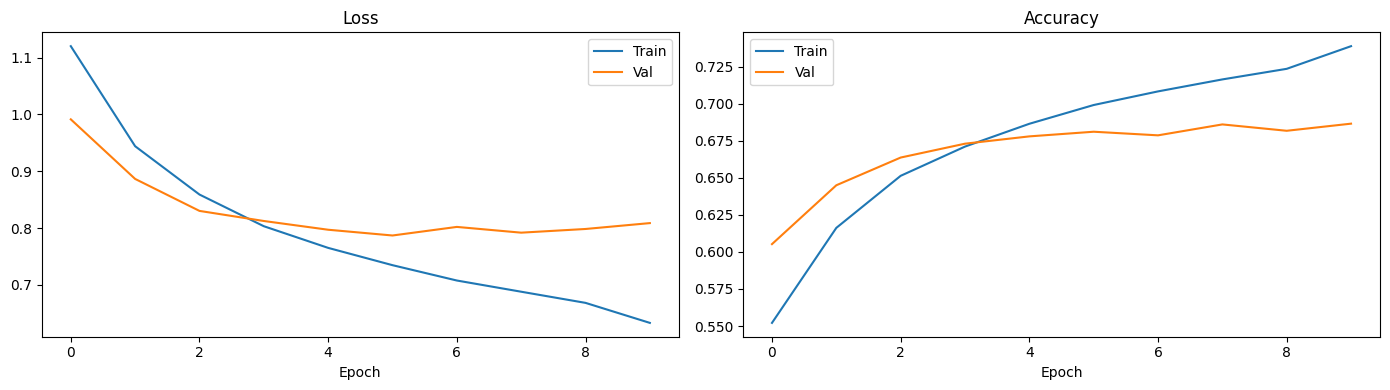

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [33]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=list(label_names.values())))

              precision    recall  f1-score   support

    Negative       0.50      0.39      0.44       707
Somewhat Neg       0.59      0.56      0.57      2727
     Neutral       0.76      0.83      0.79      7958
Somewhat Pos       0.62      0.57      0.59      3293
    Positive       0.58      0.51      0.55       921

    accuracy                           0.69     15606
   macro avg       0.61      0.57      0.59     15606
weighted avg       0.68      0.69      0.68     15606



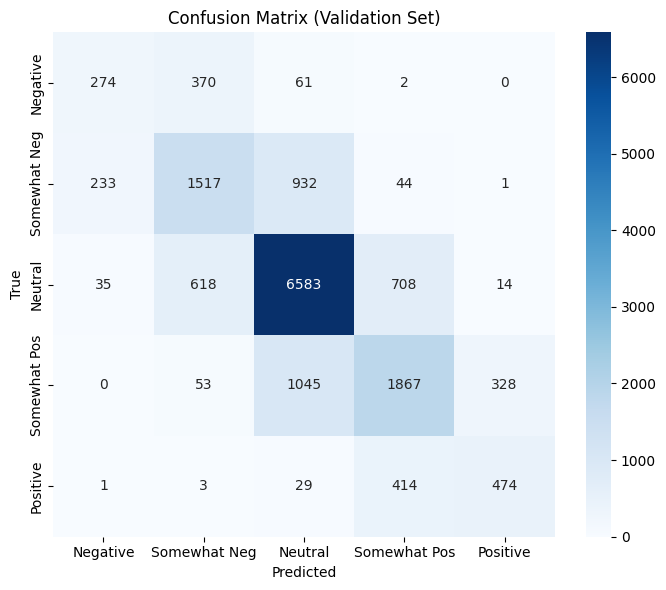

In [34]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_names.values()),
            yticklabels=list(label_names.values()))
plt.title('Confusion Matrix (Validation Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Generate Test Predictions & Submission

In [35]:
model.eval()
test_preds = []
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        test_preds.extend(preds)

submission = pd.DataFrame({'PhraseId': test_df['PhraseId'], 'Sentiment': test_preds})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved')
submission.head()

submission.csv saved


,PhraseId,Sentiment
0,156061,2
1,156062,2
2,156063,2
3,156064,2
4,156065,2
